In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# Data Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
test_gen = ImageDataGenerator(rescale=1./255)

In [3]:
# Load Data
train_data = train_gen.flow_from_directory(
    'intel/seg_train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    'intel/seg_train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    'intel/seg_test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse'
)

Found 11228 images belonging to 1 classes.
Found 2806 images belonging to 1 classes.
Found 3000 images belonging to 1 classes.


In [4]:
vgg_base = VGG16(
    weights='imagenet',       # pretrained weights
    include_top=False,        # exclude VGG's own Dense layers
    input_shape=(128, 128, 3)
)

# Freeze all VGG16 layers — we only train our custom head
vgg_base.trainable = False

In [12]:
model = models.Sequential([

    vgg_base,   

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(6, activation='softmax')  
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,077,574 (72.78 MB)

 Trainable params: 4,361,350 (16.64 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 893s 3s/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 4.9655e-05
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - accuracy: 1.0000 - loss: 5.0881e-04 - val_accuracy: 1.0000 - val_loss: 1.3038e-05
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 1.0000 - loss: 1.5532e-04 - val_accuracy: 1.0000 - val_loss: 5.1269e-06
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 1.0000 - loss: 8.3885e-05 - val_accuracy: 1.0000 - val_loss: 2.8868e-06
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 1.0000 - loss: 5.5634e-05 - val_accuracy: 1.0000 - val_loss: 1.5231e-06


In [16]:
# Evaluate
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 88s 931ms/step - accuracy: 1.0000 - loss: 1.5421e-06
Test Accuracy: 1.0


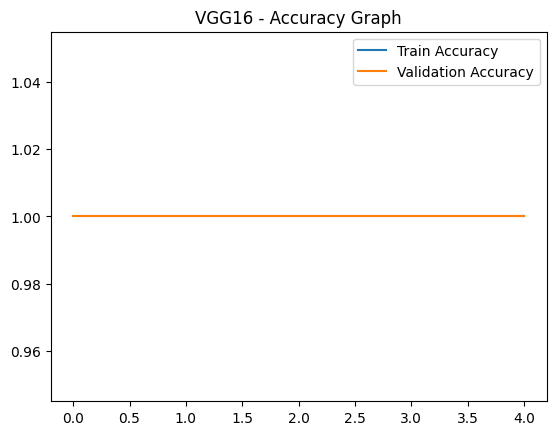

In [17]:
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("VGG16 - Accuracy Graph")
plt.show()

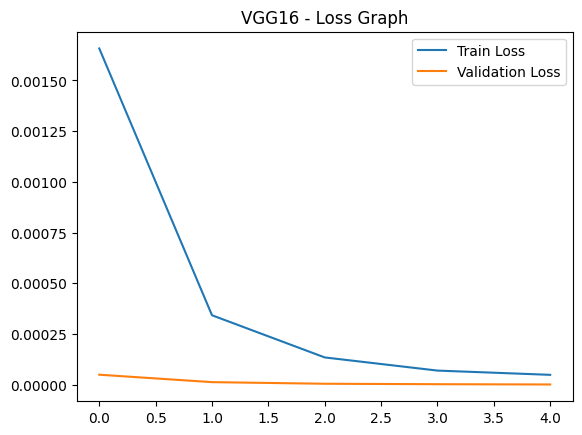

In [18]:
# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("VGG16 - Loss Graph")
plt.show()